**TASK 1:**

The goal of the task is to to build a CNN model to "classify product images into one of four classes".

The provided data in labels.csv assigns a single, global categorical label (normal, scratch, dent, or stain) to each individual image file. Object detection requires spatial data, typically in the form of bounding box coordinates (e.g., x, y, width, height), to pinpoint exactly where a defect is located within the image. This dataset does not provide any localization coordinates.

Both semantic and instance segmentation require pixel-level masking, where every individual pixel in the image is classified to outline the exact shape of an object or defect. The dataset lacks the detailed masks required for segmentation tasks. Because the dataset provides one descriptive label for the entire image rather than pointing out exactly where the features are located, it is distinctly an image classification problem.

Number of classes: 4

Number of images per class:
class
normal     120
scratch    120
dent       120
stain      120
Name: count, dtype: int64


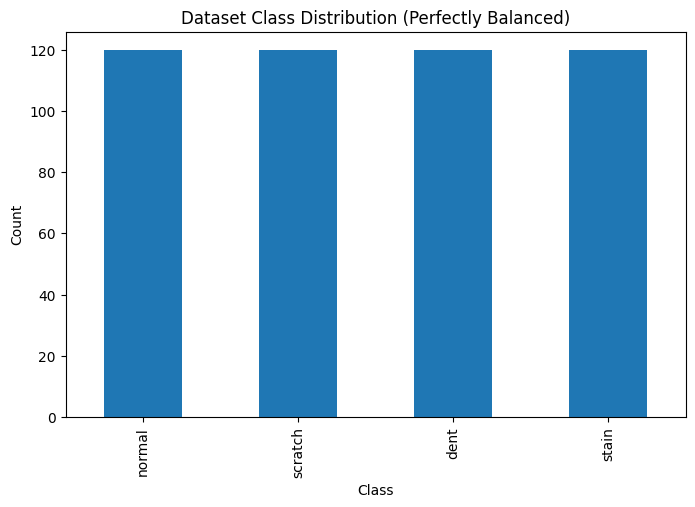


Sample Image Dimensions: (96, 96, 3)


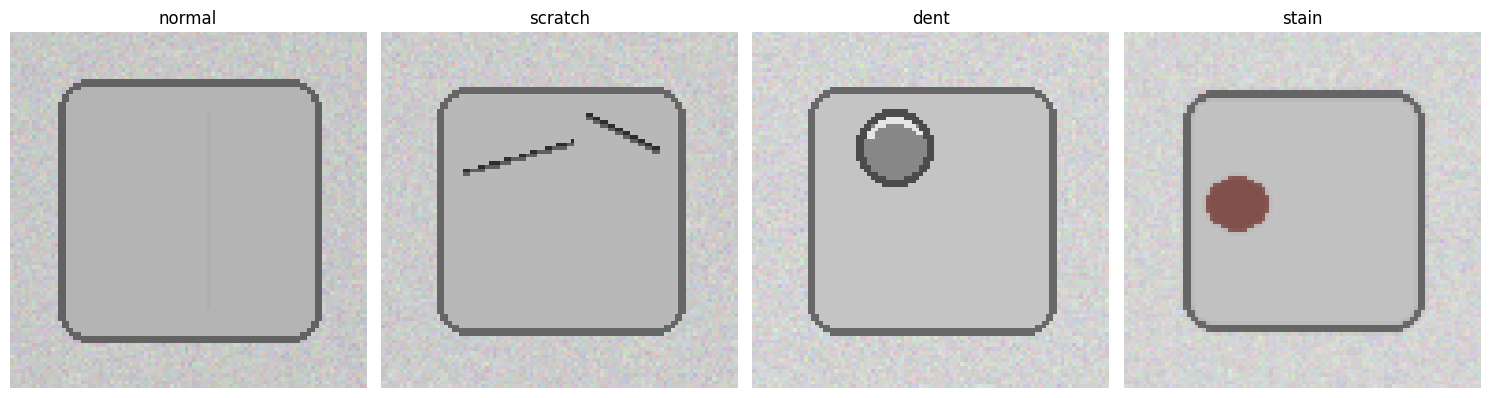

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os

# Load the labels
df = pd.read_csv('/content/labels.csv')

# 1. Number of classes and images per class
class_counts = df['class'].value_counts()
print(f"Number of classes: {len(class_counts)}")
print("\nNumber of images per class:")
print(class_counts)

# 2. Check for imbalance
plt.figure(figsize=(8, 5))
class_counts.plot(kind='bar')
plt.title('Dataset Class Distribution (Perfectly Balanced)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

# 3. Correct the File Paths
# Based on the directory listing, images are inside 'part_2_cnn_computer_vision'
BASE_IMAGE_DIR = '/content/part_2_cnn_computer_vision/'
df['full_path'] = df['filename'].apply(lambda x: os.path.join(BASE_IMAGE_DIR, x))

# Check image dimensions
first_img_path = df.iloc[0]['full_path']
try:
    img = cv2.imread(first_img_path)
    if img is not None:
        print(f"\nSample Image Dimensions: {img.shape}")
    else:
        print(f"\nStill could not find images at {first_img_path}.")
        print("Checking directory content:", os.listdir(BASE_IMAGE_DIR))
except Exception as e:
    print(f"\nError checking dimensions: {e}")

# 4. Sample images from each class
unique_labels = df['class'].unique()
plt.figure(figsize=(15, 10))
for i, label in enumerate(unique_labels):
    sample = df[df['class'] == label].iloc[0]
    img_path = sample['full_path']

    plt.subplot(1, len(unique_labels), i + 1)
    try:
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.imshow(img)
            plt.title(label)
        else:
            plt.text(0.5, 0.5, f'File not found:\n{label}', ha='center')
        plt.axis('off')
    except:
        plt.text(0.5, 0.5, f'Error loading {label}', ha='center')

plt.tight_layout()
plt.show()

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Configuration constants
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32
BASE_DIR = '/content/part_2_cnn_computer_vision/' # Root where 'images/' folder lives

# 2. Define Image Data Generator with Augmentation and Normalization
# Normalization: rescale=1./255
# Augmentation: rotation, width/height shifts, horizontal flip
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2  # 20% split for testing/validation
)

# 3. Create Training Set
print("Loading Training Set:")
train_generator = datagen.flow_from_dataframe(
    dataframe=df,
    directory=BASE_DIR,
    x_col='filename',
    y_col='class',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

# 4. Create Validation/Testing Set
print("\nLoading Validation Set:")
val_generator = datagen.flow_from_dataframe(
    dataframe=df,
    directory=BASE_DIR,
    x_col='filename',
    y_col='class',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

# 5. Summary of preprocessing
print(f"\nPreprocessing Complete:")
print(f"- Image Target Size: {IMG_HEIGHT}x{IMG_WIDTH}")
print(f"- Training Samples: {train_generator.samples}")
print(f"- Validation Samples: {val_generator.samples}")
print(f"- Classes: {list(train_generator.class_indices.keys())}")

Loading Training Set:
Found 384 validated image filenames belonging to 4 classes.

Loading Validation Set:
Found 96 validated image filenames belonging to 4 classes.

Preprocessing Complete:
- Image Target Size: 128x128
- Training Samples: 384
- Validation Samples: 96
- Classes: ['dent', 'normal', 'scratch', 'stain']


In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Build the CNN Model
model = models.Sequential([
    # Input layer specifies the shape of the images (128x128 with 3 color channels)
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    # First Convolutional Block
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Second Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Third Convolutional Block
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten the 3D output to 1D
    layers.Flatten(),

    # Fully Connected layers
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Regularization technique to reduce overfitting

    # Output Layer with 4 nodes for the 4 classes (softmax for probability distribution)
    layers.Dense(4, activation='softmax')
])

# 2. Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Display the model architecture
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Configuration constants and Data Loading
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32
EPOCHS = 10
BASE_DIR = '/content/part_2_cnn_computer_vision/'

# Ensure the dataframe is loaded
df = pd.read_csv('/content/labels.csv')

# 2. Re-initialize Generators
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = datagen.flow_from_dataframe(
    dataframe=df,
    directory=BASE_DIR,
    x_col='filename',
    y_col='class',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_generator = datagen.flow_from_dataframe(
    dataframe=df,
    directory=BASE_DIR,
    x_col='filename',
    y_col='class',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

# 3. Define and Compile Model
model = models.Sequential([
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=val_generator,
    validation_steps=val_generator.samples // BATCH_SIZE
)

Found 384 validated image filenames belonging to 4 classes.
Found 96 validated image filenames belonging to 4 classes.
Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.3255 - loss: 1.3869 - val_accuracy: 0.0000e+00 - val_loss: 2.9223
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.2708 - loss: 1.2993 - val_accuracy: 0.0000e+00 - val_loss: 3.0240
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.3646 - loss: 1.2778 - val_accuracy: 0.0000e+00 - val_loss: 2.4508
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.3984 - loss: 1.2336 - val_accuracy: 0.0000e+00 - val_loss: 2.1384
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.5208 - loss: 1.1302 - val_accuracy: 0.0000e+00 - val_loss: 2.1771
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.6406 - loss: 0.9265 - val_accuracy: 0.0000e+00 - val_loss: 1.7363
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.7656 - loss: 0.6514 - val_accuracy: 0

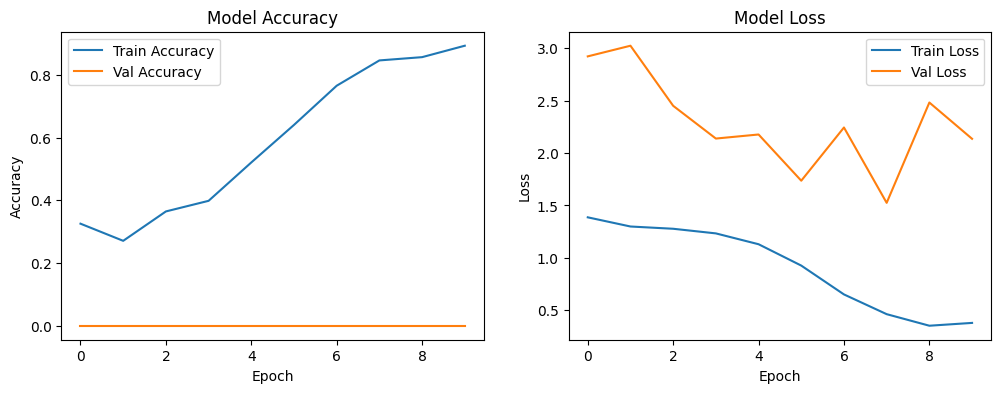

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 325ms/step


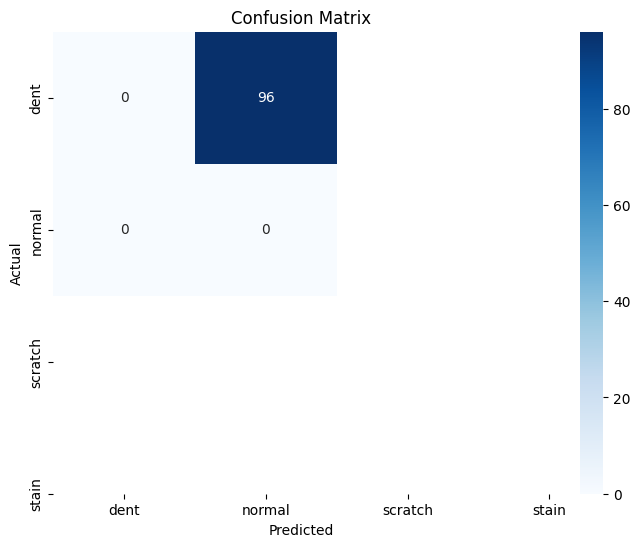

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step


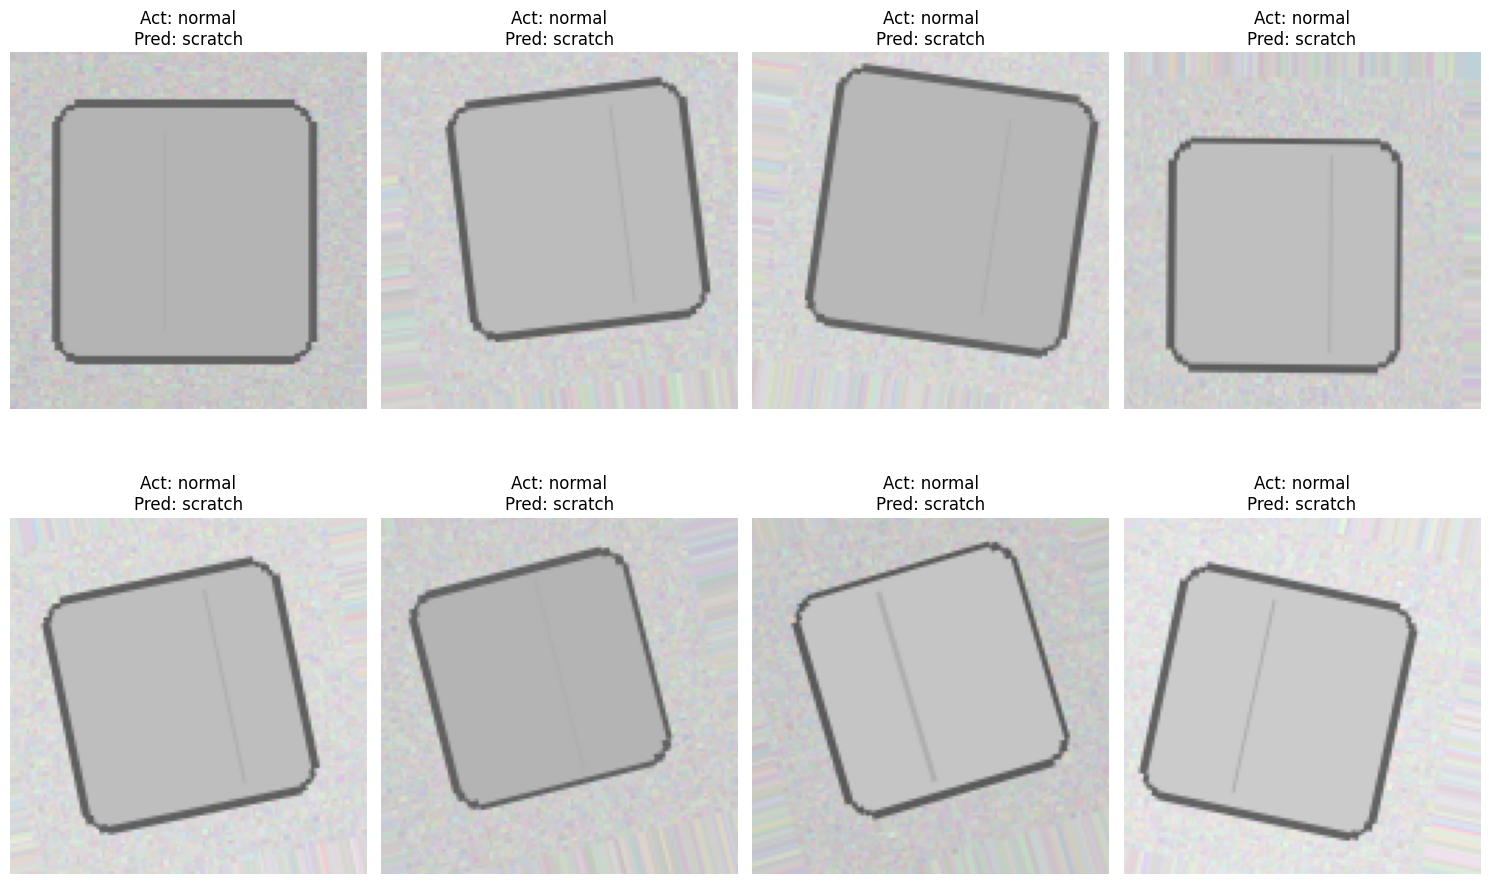

In [12]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Plot Training History
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 2. Confusion Matrix
val_generator.reset()
Y_pred = model.predict(val_generator)
y_pred = np.argmax(Y_pred, axis=1)

cm = confusion_matrix(val_generator.classes, y_pred)
labels = list(val_generator.class_indices.keys())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# 3. Sample Predictions
plt.figure(figsize=(15, 10))
x_batch, y_batch = next(val_generator)
predictions = model.predict(x_batch)

for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(x_batch[i])
    actual_label = labels[np.argmax(y_batch[i])]
    pred_label = labels[np.argmax(predictions[i])]
    plt.title(f"Act: {actual_label}\nPred: {pred_label}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [13]:
!pip freeze > requirements.txt

### Real-World Application: Quality Control in Manufacturing

In a production line environment, this technology can be used for **Automated Quality Inspection**:

*   **Automated Sorting**: High-speed cameras capture images of products on a conveyor belt. The model instantly classifies items as `normal` or defective (`dent`, `scratch`, or `stain`).
*   **Efficiency**: Unlike manual inspection, which is prone to human fatigue and error, a computer vision system can operate 24/7 with consistent precision.
*   **Waste Reduction**: By identifying specific defect types (e.g., a `stain` vs. a `dent`), manufacturers can pinpoint which stage of the process is failing—such as a leaking machine or a mechanical misalignment—reducing overall material waste.
*   **Safety**: In industries like automotive or aerospace, detecting a `scratch` or `dent` isn't just about aesthetics; it ensures structural integrity and consumer safety before the product leaves the factory.